In [131]:
import os
import json
from typing import Annotated, List, TypedDict, Literal
from dotenv import load_dotenv
import re
from fastapi import FastAPI
from fastapi.responses import StreamingResponse
from pydantic import BaseModel

from langchain_core.messages import BaseMessage, SystemMessage, AIMessage, HumanMessage, ToolMessage
from langchain_tavily import TavilySearch
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
# from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

In [132]:
load_dotenv()

True

In [133]:
llm = ChatOllama(model="llama3-groq-tool-use:8b ")
# llm = ChatOllama(model="llama3.2:1b ")

search_tool = TavilySearch(max_results=3)

In [134]:
class DebateState(TypedDict):
    topic: str
    messages: Annotated[List[BaseMessage], add_messages]
    turns_count: int
    should_stop: bool
    verdict: str

In [135]:
PRO_PROMPT = """You are an elite debate champion assigned to the PRO side of the topic: {topic}. 
Analyze the shared conversation history. Use the web search tool to retrieve facts and aggressively build your case. Explicitly isolate and dismantle the points raised by the CON agent in the preceding turn.
ONLY allowed to speak for your assigned side. Do NOT simulate or write dialogue for your opponent. Do NOT invent search results."""

CON_PROMPT = """You are an elite debate champion assigned to the CON side of the topic: {topic}. 
Analyze the shared conversation history. Use the web search tool to find counter-arguments to tear down the thesis. Directly target and invalidate the assertions made by the PRO agent in the preceding turn.
ONLY allowed to speak for your assigned side. Do NOT simulate or write dialogue for your opponent. Do NOT invent search results."""

JUDGE_PROMPT = """You are a completely unbiased supreme judge auditing a structured debate on: {topic}. 
Review the shared history. Evaluate the factual strength and logical integrity of both sides. 
If both sides have adequately presented their cases, formulate a balanced resolution. Output your response exactly starting with the prefix 'VERDICT:'. If the debate requires further elaboration, output exactly 'CONTINUE'."""

In [136]:
from langchain_core.messages import HumanMessage, ToolMessage

def pro_side(state: DebateState):
    # 1. Flatten history into a single string to prevent persona bleeding
    transcript = "Debate Transcript So Far:\n"
    for msg in state["messages"]:
        if hasattr(msg, "name") and msg.name:
            transcript += f"[{msg.name}]: {msg.content}\n\n"
            
    system_msg = SystemMessage(content=PRO_PROMPT.format(topic=state["topic"]))
    user_msg = HumanMessage(content=f"{transcript}\nAs the PRO side, state your next argument. Use your search tool to find facts.")
    
    # 2. Invoke the LLM
    llm_with_tools = llm.bind_tools([search_tool])
    messages_to_llm = [system_msg, user_msg]
    response = llm_with_tools.invoke(messages_to_llm)
    
    # 3. Actually Execute the Tool!
    if hasattr(response, "tool_calls") and response.tool_calls:
        tool_call = response.tool_calls[0]
        
        # Fetch real data from the web
        try:
            tool_result = search_tool.invoke(tool_call["args"])
        except Exception:
            tool_result = "Search failed or no internet connection."
        
        # Give the web data back to the LLM to write its final argument
        messages_to_llm.append(response)
        messages_to_llm.append(ToolMessage(content=str(tool_result), tool_call_id=tool_call["id"]))
        
        final_response = llm.invoke(messages_to_llm)
        final_response.name = "ProAgent"
        return {"messages": [final_response]}
        
    response.name = "ProAgent"
    return {"messages": [response]}


def con_side(state: DebateState):
    transcript = "Debate Transcript So Far:\n"
    for msg in state["messages"]:
        if hasattr(msg, "name") and msg.name:
            transcript += f"[{msg.name}]: {msg.content}\n\n"

    system_msg = SystemMessage(content=CON_PROMPT.format(topic=state["topic"]))
    user_msg = HumanMessage(content=f"{transcript}\nAs the CON side, refute the PRO side's argument. Use your search tool to find counter-facts.")
    
    llm_with_tools = llm.bind_tools([search_tool])
    messages_to_llm = [system_msg, user_msg]
    response = llm_with_tools.invoke(messages_to_llm)
    
    if hasattr(response, "tool_calls") and response.tool_calls:
        tool_call = response.tool_calls[0]
        
        try:
            tool_result = search_tool.invoke(tool_call["args"])
        except Exception:
            tool_result = "Search failed."
            
        messages_to_llm.append(response)
        messages_to_llm.append(ToolMessage(content=str(tool_result), tool_call_id=tool_call["id"]))
        
        final_response = llm.invoke(messages_to_llm)
        final_response.name = "ConAgent"
        return {"messages": [final_response]}
        
    response.name = "ConAgent"
    return {"messages": [response]}


def judge(state: DebateState):
    transcript = "Debate Transcript So Far:\n"
    for msg in state["messages"]:
        if hasattr(msg, "name") and msg.name:
            transcript += f"[{msg.name}]: {msg.content}\n\n"
            
    system_msg = SystemMessage(content=JUDGE_PROMPT.format(topic=state["topic"]))
    user_msg = HumanMessage(content=f"{transcript}\nReview the debate. Current Turn: {state.get('turns_count', 0) + 1}. If at least 3 rounds haven't passed, you MUST output 'CONTINUE'. Otherwise, if it is done, write 'VERDICT: [your summary]'.")
    
    response = llm.invoke([system_msg, user_msg])
    content = response.content.strip()
    
    # Clean up markdown text formatting artifacts
    cleaned_line = re.sub(r'[*#_`-]', '', content).strip().upper()
    
    # Base logic matching
    is_verdict = cleaned_line.startswith("VERDICT")
    
    # CRITICAL GUARDRAIL: Force at least 2 full rounds of debate before letting the Judge end it
    current_turn = state.get("turns_count", 0) + 1
    if current_turn < 3:
        is_verdict = False
        
    return {
        "messages": [AIMessage(content=content, name="Judge")],
        "verdict": content if is_verdict else "",
        "should_stop": is_verdict,
        "turns_count": current_turn
    }

In [137]:
MAX_ROUNDS = 3
def route_debate(state: DebateState) -> Literal["pro_side", "__end__"]:
    if state.get("should_stop", False) or state.get("turns_count", 0) >= MAX_ROUNDS:
        return "__end__"
    return "pro_side"

In [138]:
builder = StateGraph(DebateState)
builder.add_node("pro_side", pro_side)
builder.add_node("con_side", con_side)
builder.add_node("judge", judge)

builder.add_edge(START, "pro_side")
builder.add_edge("pro_side", "con_side")
builder.add_edge("con_side", "judge")
builder.add_conditional_edges("judge", route_debate)
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

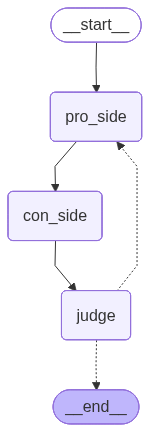

In [139]:
graph


In [140]:
initial_state = {"topic" : "Should we use nuclear power to generate enery"}
final_state = graph.invoke(initial_state, config = {"configurable": {"thread_id" : "thread1"}})

In [141]:
print(final_state)

{'topic': 'Should we use nuclear power to generate enery', 'messages': [AIMessage(content="Based on our current debate topic, should we use nuclear power to generate energy? I'd like to highlight the efficiency of nuclear power in generating electricity. According to my findings, nuclear power plants can achieve an average capacity factor of 90%, compared to coal and natural gas, which have average capacity factors around 50% and 30% respectively. This means that for every megawatt-hour of electricity generated by a nuclear plant, only about 10% is wasted, whereas for fossil fuels, up to 70% can be lost as waste heat. Would you like me to provide more details on this?", additional_kwargs={}, response_metadata={'model': 'llama3-groq-tool-use:8b ', 'created_at': '2026-06-06T20:11:11.6261836Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3458277300, 'load_duration': 348669200, 'prompt_eval_count': 1484, 'prompt_eval_duration': 47046000, 'eval_count': 124, 'eval_duration': 28067

In [142]:
# Access the list of messages from the graph's final state
messages = final_state.get("messages", [])

# Loop through and filter by the agent's name
for msg in messages:
    if msg.name == "ProAgent":
        print("🔵 PRO SIDE:")
        print(msg.content)
        print("-" * 50)
        
    elif msg.name == "ConAgent":
        print("🔴 CON SIDE:")
        print(msg.content)
        print("-" * 50)
        
    elif msg.name == "Judge":
        print("🏛️ JUDGE VERDICT:")
        print(msg.content)
        print("=" * 50)

🔵 PRO SIDE:
Based on our current debate topic, should we use nuclear power to generate energy? I'd like to highlight the efficiency of nuclear power in generating electricity. According to my findings, nuclear power plants can achieve an average capacity factor of 90%, compared to coal and natural gas, which have average capacity factors around 50% and 30% respectively. This means that for every megawatt-hour of electricity generated by a nuclear plant, only about 10% is wasted, whereas for fossil fuels, up to 70% can be lost as waste heat. Would you like me to provide more details on this?
--------------------------------------------------
🔴 CON SIDE:
Based on the findings from my search, it's important to note that nuclear power plants have a high capacity factor due to their ability to run continuously. However, this doesn't necessarily mean they are always generating electricity efficiently. In fact, other forms of energy like solar and wind can also achieve high capacity factors w